In [1]:
import numpy as np
import matplotlib.pyplot as plt

import clmm

H0 = 70.0
OMEGA_M = 0.3
OMEGA_B = 0.045
C_LIGHT = 299792.458  # km/s

# Overall prefactor in Eq. (2). It cancels in the normalized plots,
# but keeping it makes q_i the physical lensing efficiency kernel.
LENSING_PREFACTOR = 1.5 * OMEGA_M * (H0 / C_LIGHT) ** 2

cosmo = clmm.Cosmology(
    H0=H0,
    Omega_dm0=OMEGA_M - OMEGA_B,
    Omega_b0=OMEGA_B,
    Omega_k0=0.0,
)


In [2]:
# Redshift grid where we evaluate the lensing kernels.
z_grid = np.linspace(0.001, 2.5, 1500)

# Single-source-plane case:
# 20 individual source galaxies/source planes between z=0.1 and z=2.0.
n_sources = 20
z_sources = np.linspace(0.1, 2.0, n_sources)

print("Source redshifts:")
print(z_sources)

Source redshifts:
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2. ]


In [3]:
def chi_of_z(z):
    """
    Return comoving distance chi(z).

    CLMM's eval_da gives angular diameter distance D_A(z).
    Comoving distance is chi(z) = D_A(z) * (1 + z).
    """
    return cosmo.eval_da(z) * (1.0 + z)


chi_grid = np.array([chi_of_z(z) for z in z_grid])
chi_sources = np.array([chi_of_z(zs) for zs in z_sources])

print("Source comoving distances:")
print(chi_sources)

Source comoving distances:
[ 418.41021955  816.55202238 1194.02673478 1550.91714367 1887.68974584
 2205.09210733 2504.05915936 2785.63559486 3050.91479332 3300.99445281
 3536.94574609 3759.79314935 3970.50295804 4169.97741666 4359.05249836
 4538.49882768 4709.02466107 4871.279067   5025.85536545 5173.29725355]


In [4]:
def single_source_lensing_kernel(z_lens, chi_lens, chi_source):
    """
    Lensing efficiency kernel for a single source plane.

    This is Eq. (2) of the paper with
        n_i(chi') = delta_D(chi' - chi_source).

    For matter at comoving distance chi_lens and source at chi_source:

        q(chi) = (3/2) Omega_m (H0/c)^2
                 * chi / a(chi)
                 * (chi_source - chi) / chi_source

    for chi_lens < chi_source, and q = 0 otherwise.
    """
    q = np.zeros_like(chi_lens)

    mask = chi_lens < chi_source

    q[mask] = (
        LENSING_PREFACTOR
        * chi_lens[mask]
        * (1.0 + z_lens[mask])
        * (chi_source - chi_lens[mask])
        / chi_source
    )

    return q


In [5]:
# q has shape:
#   number of source galaxies x number of redshift-grid points
#
# Each row is the physical lensing efficiency kernel for one source
# galaxy/source plane. The normalized copy is only for plotting, as in Fig. 1.

q = np.zeros((n_sources, len(z_grid)))
q_plot = np.zeros_like(q)

for i, chi_s in enumerate(chi_sources):
    q_i = single_source_lensing_kernel(z_grid, chi_grid, chi_s)
    q[i] = q_i

    # Normalize each original kernel by its own peak for plotting only.
    max_q = np.max(q_i)
    if max_q > 0:
        q_plot[i] = q_i / max_q

print("q shape:", q.shape)


q shape: (20, 1500)


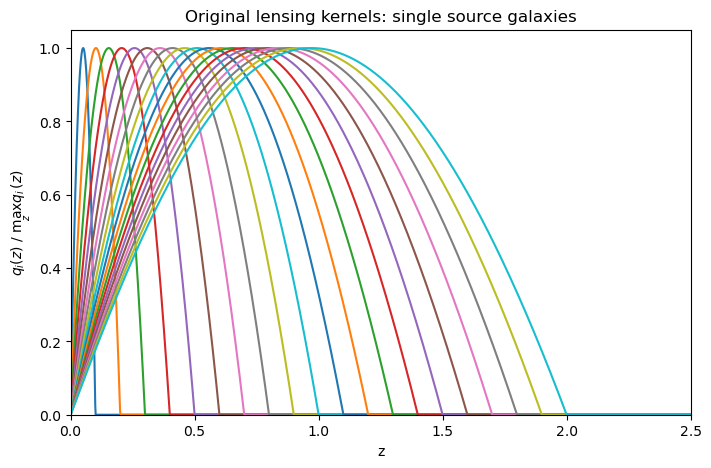

In [6]:
plt.figure(figsize=(8, 5))

for i in range(n_sources):
    plt.plot(z_grid, q_plot[i])

plt.xlabel("z")
plt.ylabel(r"$q_i(z)$ / $\max_z q_i(z)$")
plt.title("Original lensing kernels: single source galaxies")
plt.xlim(0, 2.5)
plt.ylim(0, 1.05)
plt.show()


In [7]:
def build_bnt_matrix_single_sources(chi_sources):
    """
    Build the BNT matrix for single source planes.

    For the single-source case, the BNT nulling conditions are:

        sum_j M_ij = 0

    and

        sum_j M_ij / chi_j = 0

    using three neighboring source planes:
        i-2, i-1, i

    We set M_ii = 1 and solve for the other two coefficients.
    """

    n = len(chi_sources)
    M = np.zeros((n, n))

    # First source bin is unchanged.
    M[0, 0] = 1.0

    # Second row is a simple difference.
    # True three-source nulling starts at i=2.
    M[1, 0] = -1.0
    M[1, 1] = 1.0

    for i in range(2, n):
        chi_im2 = chi_sources[i - 2]
        chi_im1 = chi_sources[i - 1]
        chi_i = chi_sources[i]

        a = (
            (1.0 / chi_im1 - 1.0 / chi_i)
            / (1.0 / chi_im2 - 1.0 / chi_im1)
        )

        b = -1.0 - a

        M[i, i - 2] = a
        M[i, i - 1] = b
        M[i, i] = 1.0

    return M


M = build_bnt_matrix_single_sources(chi_sources)

print("M shape:", M.shape)
print(M)

M shape: (20, 20)
[[ 1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [-1.          1.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.3322296  -1.3322296   1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.49778554 -1.49778554  1.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.59687764 -1.59687764  1.          0.
   0.          0

In [8]:
# Apply the BNT transformation to the physical, unnormalized kernels.
# The peak normalization is only for plotting, matching Fig. 1.

q_tilde = M @ q

q_tilde_norm = np.zeros_like(q_tilde)

for i in range(n_sources):
    max_q_tilde = np.max(q_tilde[i])
    if max_q_tilde > 0:
        q_tilde_norm[i] = q_tilde[i] / max_q_tilde

print("q_tilde shape:", q_tilde.shape)


q_tilde shape: (20, 1500)


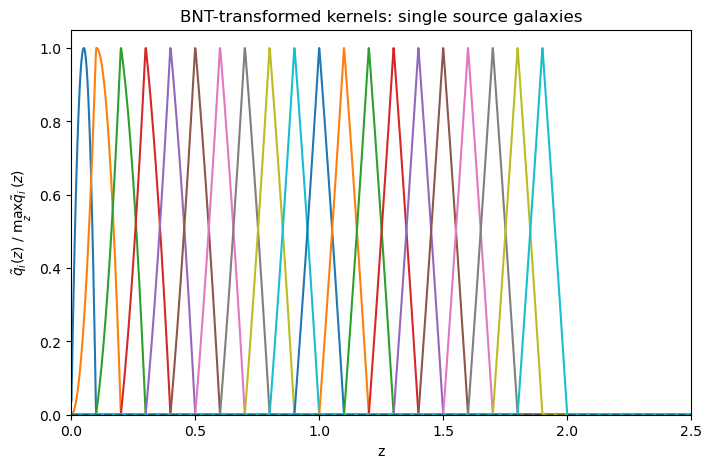

In [9]:
plt.figure(figsize=(8, 5))

for i in range(n_sources):
    plt.plot(z_grid, q_tilde_norm[i])

plt.xlabel("z")
plt.ylabel(r"$\tilde{q}_i(z)$ / $\max_z \tilde{q}_i(z)$")
plt.title("BNT-transformed kernels: single source galaxies")
plt.xlim(0, 2.5)
plt.ylim(0, 1.05)
plt.axhline(0, color="k", linestyle="--", alpha=0.4)
plt.show()


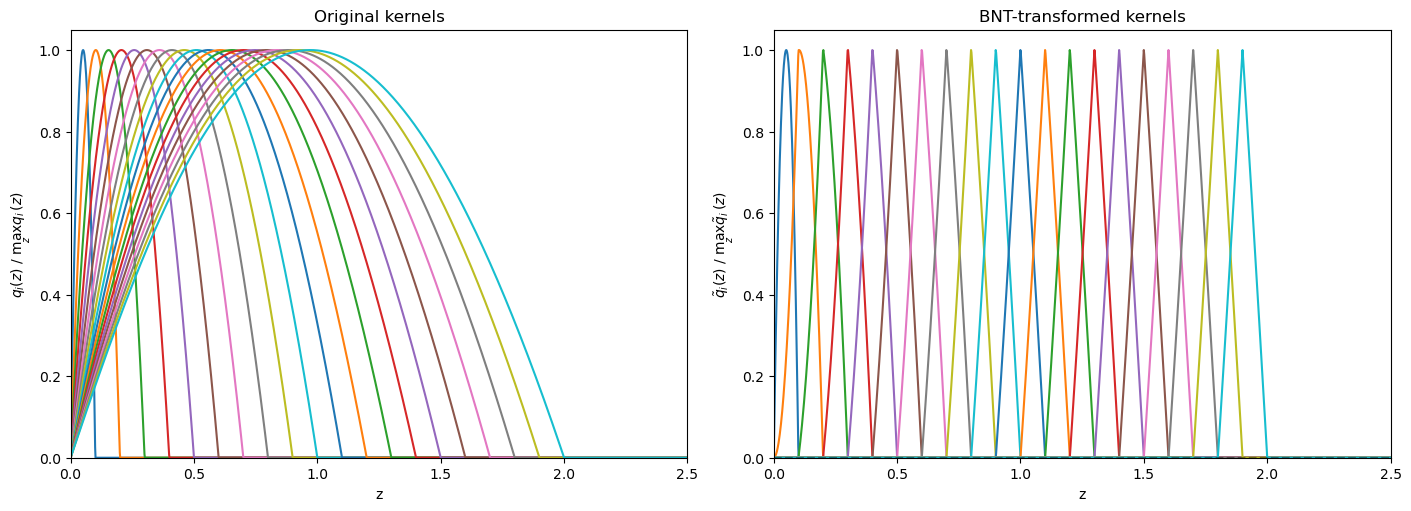

In [10]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 5), layout="constrained")

for i in range(n_sources):
    axs[0].plot(z_grid, q_plot[i])

axs[0].set_title("Original kernels")
axs[0].set_xlabel("z")
axs[0].set_ylabel(r"$q_i(z)$ / $\max_z q_i(z)$")
axs[0].set_xlim(0, 2.5)
axs[0].set_ylim(0, 1.05)

for i in range(n_sources):
    axs[1].plot(z_grid, q_tilde_norm[i])

axs[1].set_title("BNT-transformed kernels")
axs[1].set_xlabel("z")
axs[1].set_ylabel(r"$\tilde{q}_i(z)$ / $\max_z \tilde{q}_i(z)$")
axs[1].set_xlim(0, 2.5)
axs[1].set_ylim(0, 1.05)
axs[1].axhline(0, color="k", linestyle="--", alpha=0.4)

plt.show()


What Was Going Wrong Earlier: 

1. Normalizing too early. We were computing q1 and q2 and directly normalizing them then doing Q_tilde = M @ q in the end. This affected the transformation. The paper said to do q_tilde = MQ first then normalize.plot it
2. Our q(X) kernel was incorrect. We were missing the extra 1/a(x) that the paper had. So kernel was missing a factor of 1 + z because 1/a = 1 + z.
3. negatives were caused by applying the BNT matrix to already-normalized kernels. So once kernels keep their actual amplitudes physically, the linear combinations behave much better. So figure one in paper was compute q, apply BNT, normalize only for plotting. HOwever, we were initially doing normalize, apply BNT, normalize for plotting again. 